# Phase 3 — Feature Engineering

Extract handcrafted features from all classification images for use in classical ML models.

Features extracted per image (45 total):
- **Colour (18)** — RGB + HSV channel statistics (mean, std, skewness)
- **Texture (26)** — LBP histogram from green channel
- **CDR proxy (1)** — Cup-to-Disc Ratio estimate

Output: feature matrix saved to `outputs/results/features_cache.pkl`


In [1]:
import sys
from pathlib import Path

def _find_project_root(start, marker='config.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Cannot find project root from {start}")

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: D:\Machine Learning\glaucoma detection project


In [2]:
import importlib
import features.feature_extractor as _fe
importlib.reload(_fe)
from features.feature_extractor import (
    build_feature_matrix, feature_names, extract_colour_features,
    extract_lbp_features, extract_cdr_proxy, N_TOTAL,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from config import FEATURES_CACHE, RESULTS_DIR, FIGURES_DIR, SEED
from data.dataset_loader import load_all_datasets, get_dataset_splits

plt.rcParams['figure.dpi'] = 120
print(f'Feature vector size: {N_TOTAL}')

Feature vector size: 45


## 3.1 Load datasets

In [3]:
df = load_all_datasets(include=['ACRIMA', 'RIMONE', 'AIROGS'], airogs_max_samples=2000)
print(f'Total images: {len(df)}')

[ACRIMA]  Total:   705  |  Glaucoma:  396  |  Normal:  309
[RIMONE]  Total:   485  |  Glaucoma:  172  |  Normal:  313
[AIROGS]  Total:  3540  |  Glaucoma: 1770  |  Normal: 1770

────────────────────────────────────────────────────
  COMBINED  Total   : 4730
            Glaucoma: 2338
            Normal  : 2392
────────────────────────────────────────────────────
Total images: 4730


## 3.2 Extract feature matrix
This runs in parallel across all CPU cores. Expect ~3–6 minutes for ~4700 images.

In [4]:
X, y, names, valid_df = build_feature_matrix(df, n_jobs=-1)

print(f'\nFeature names ({len(names)}): {names[:5]} ... {names[-3:]}')

Extracting features: 100%|██████████| 4730/4730 [00:22<00:00, 210.51it/s]


Feature matrix shape : (4730, 45)
Class counts         : Normal=2392  Glaucoma=2338

Feature names (45): ['RGB_R_mean', 'RGB_R_std', 'RGB_R_skew', 'RGB_G_mean', 'RGB_G_std'] ... ['LBP_bin_24', 'LBP_bin_25', 'CDR_proxy']


## 3.3 Save feature cache

In [5]:
cache = {
    'X':        X,
    'y':        y,
    'names':    names,
    'valid_df': valid_df,
}
joblib.dump(cache, FEATURES_CACHE)
print(f'Saved → {FEATURES_CACHE}')
print(f'Cache size: {FEATURES_CACHE.stat().st_size / 1024:.1f} KB')

Saved → D:\Machine Learning\glaucoma detection project\outputs\results\features_cache.pkl
Cache size: 1519.6 KB


## 3.4 Feature statistics — mean per class

In [6]:
feat_df          = pd.DataFrame(X, columns=names)
feat_df['label'] = y
feat_df['label_name'] = feat_df['label'].map({0: 'Normal', 1: 'Glaucoma'})

# Mean value per feature per class
class_means = feat_df.groupby('label_name')[names].mean()
print(class_means.T.round(4).to_string())

label_name  Glaucoma  Normal
RGB_R_mean    0.4270  0.4402
RGB_R_std     0.1946  0.2042
RGB_R_skew   -0.0931 -0.1636
RGB_G_mean    0.2473  0.2568
RGB_G_std     0.1450  0.1379
RGB_G_skew    0.5179  0.3315
RGB_B_mean    0.1386  0.1396
RGB_B_std     0.0935  0.0873
RGB_B_skew    0.8935  0.7954
HSV_H_mean    0.0925  0.0850
HSV_H_std     0.1117  0.1026
HSV_H_skew    4.1576  5.1138
HSV_S_mean    0.5517  0.5791
HSV_S_std     0.2182  0.2267
HSV_S_skew   -0.6049 -0.6075
HSV_V_mean    0.4286  0.4413
HSV_V_std     0.1951  0.2045
HSV_V_skew   -0.0955 -0.1659
LBP_bin_0     0.0365  0.0391
LBP_bin_1     0.0243  0.0256
LBP_bin_2     0.0129  0.0140
LBP_bin_3     0.0095  0.0102
LBP_bin_4     0.0084  0.0089
LBP_bin_5     0.0083  0.0086
LBP_bin_6     0.0085  0.0087
LBP_bin_7     0.0103  0.0102
LBP_bin_8     0.0125  0.0120
LBP_bin_9     0.0161  0.0151
LBP_bin_10    0.0219  0.0199
LBP_bin_11    0.0324  0.0288
LBP_bin_12    0.0397  0.0352
LBP_bin_13    0.0301  0.0273
LBP_bin_14    0.0177  0.0166
LBP_bin_15    

## 3.5 Top discriminative features (mean difference Normal vs Glaucoma)

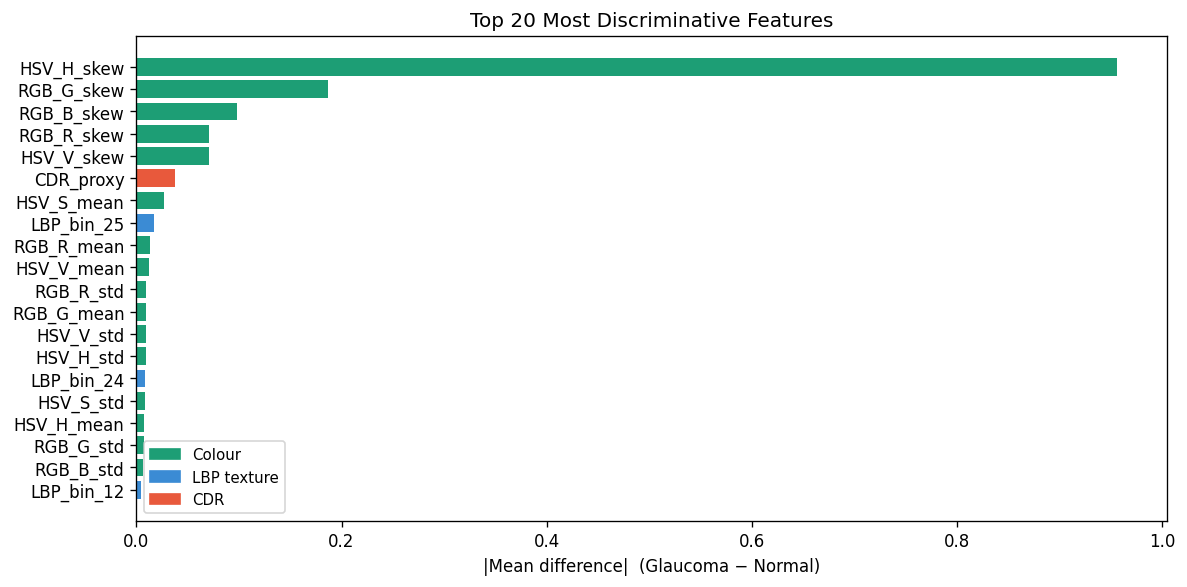

In [7]:
diff = (class_means.loc['Glaucoma'] - class_means.loc['Normal']).abs()
top20 = diff.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#E8593C' if 'CDR' in n else '#3B8BD4' if 'LBP' in n else '#1D9E75'
           for n in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1], color=colours[::-1])
ax.set_xlabel('|Mean difference|  (Glaucoma − Normal)')
ax.set_title('Top 20 Most Discriminative Features')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#1D9E75', label='Colour'),
    Patch(color='#3B8BD4', label='LBP texture'),
    Patch(color='#E8593C', label='CDR'),
], fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_features.png', bbox_inches='tight')
plt.show()

## 3.6 CDR proxy distribution — Normal vs Glaucoma

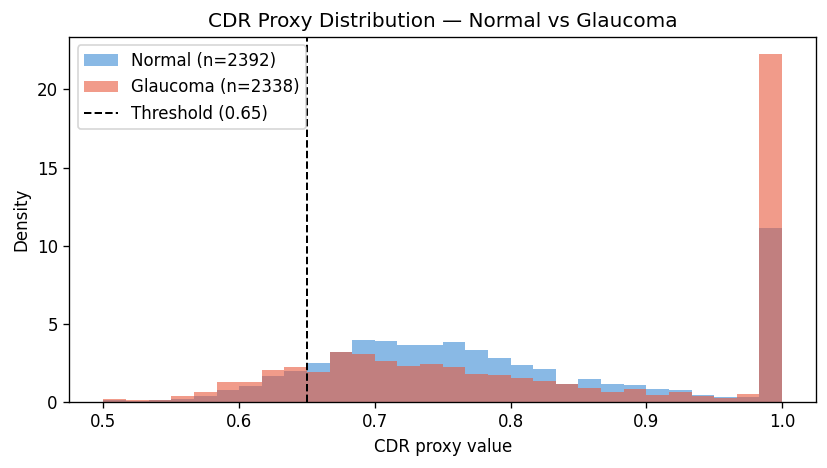

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, name, colour in [(0, 'Normal', '#3B8BD4'), (1, 'Glaucoma', '#E8593C')]:
    vals = feat_df[feat_df['label'] == label]['CDR_proxy']
    ax.hist(vals, bins=30, alpha=0.6, color=colour, label=f'{name} (n={len(vals)})', density=True)

ax.axvline(0.65, color='black', linestyle='--', linewidth=1.2, label='Threshold (0.65)')
ax.set_xlabel('CDR proxy value')
ax.set_ylabel('Density')
ax.set_title('CDR Proxy Distribution — Normal vs Glaucoma')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cdr_proxy_distribution.png', bbox_inches='tight')
plt.show()

## 3.7 Feature correlation heatmap (colour features only)

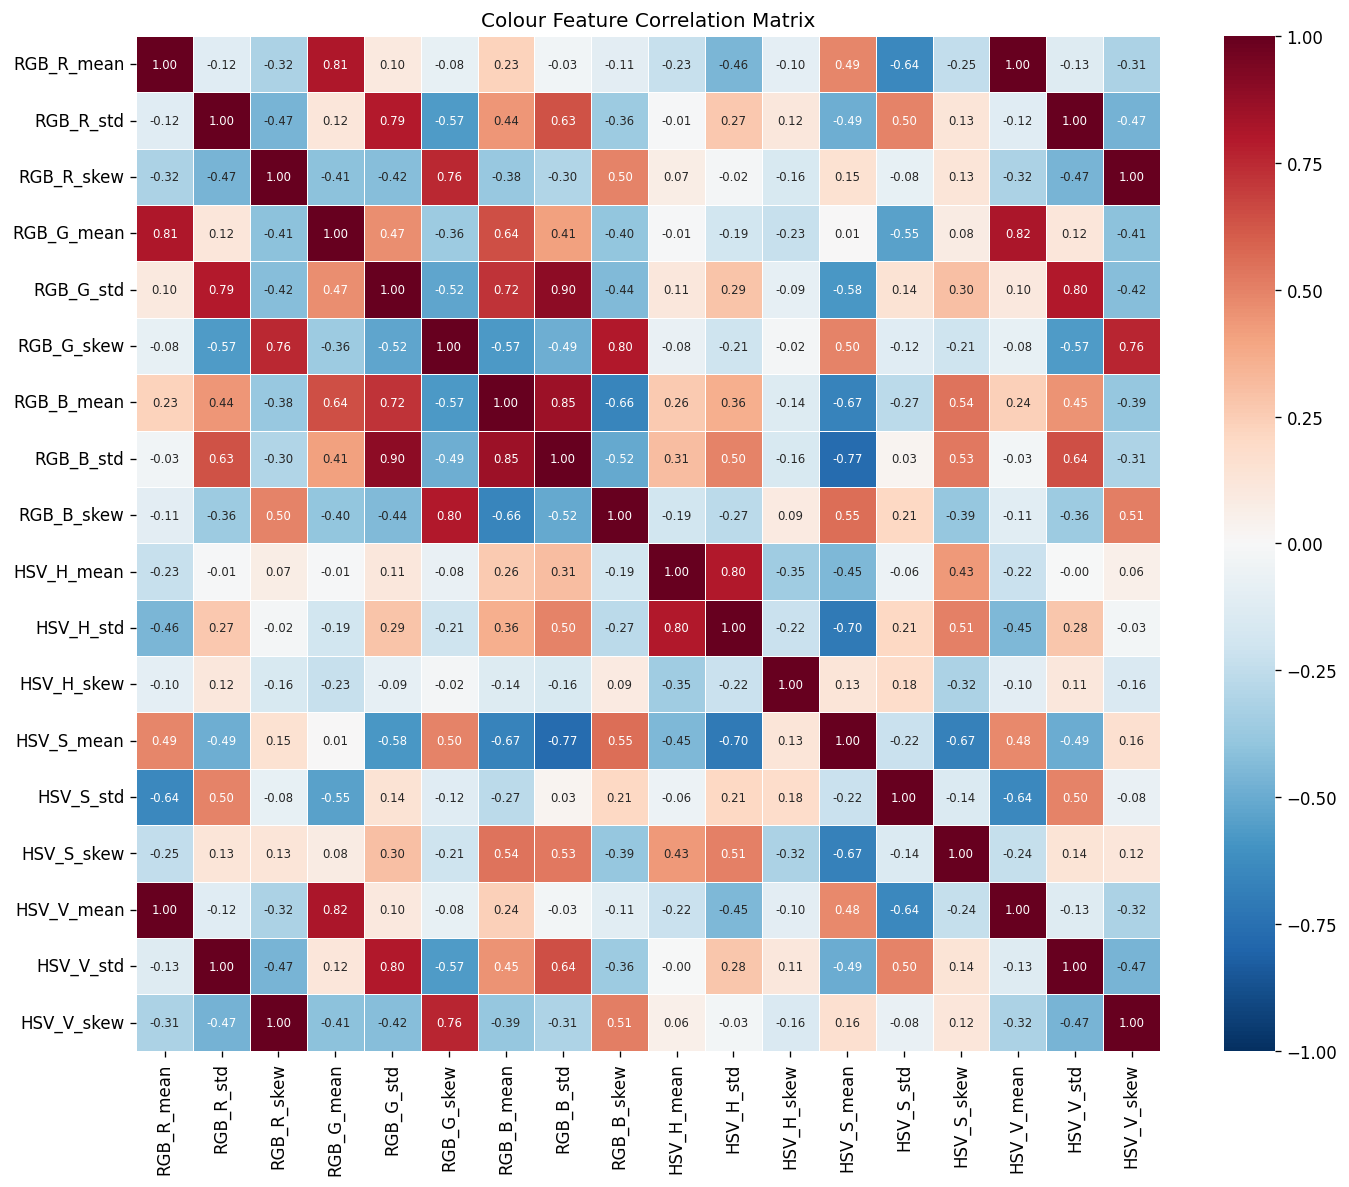

In [9]:
colour_cols = [n for n in names if n.startswith('RGB') or n.startswith('HSV')]
corr = feat_df[colour_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, linewidths=0.3, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Colour Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'colour_feature_correlation.png', bbox_inches='tight')
plt.show()

## 3.8 PCA — 2D visualisation of feature space

In [10]:
# ── NaN diagnostic + imputation ──────────────────────────────────────
# Skewness returns NaN for near-constant channels (black-border images).
# Impute with column median so PCA/sklearn models never see NaN.
from sklearn.impute import SimpleImputer

nan_counts = np.isnan(X).sum(axis=0)
nan_features = [(names[i], int(nan_counts[i])) for i in range(len(names)) if nan_counts[i] > 0]

if nan_features:
    print(f'NaN found in {len(nan_features)} feature(s):')
    for fname, cnt in nan_features:
        print(f'  {fname}: {cnt} NaN values')
    imputer = SimpleImputer(strategy='median')
    X_scaled = imputer.fit_transform(X_scaled)
    print(f'Imputed with column medians. NaN remaining: {np.isnan(X_scaled).sum()}')
else:
    print('No NaN values in feature matrix. Ready for PCA.')


No NaN values in feature matrix. Ready for PCA.


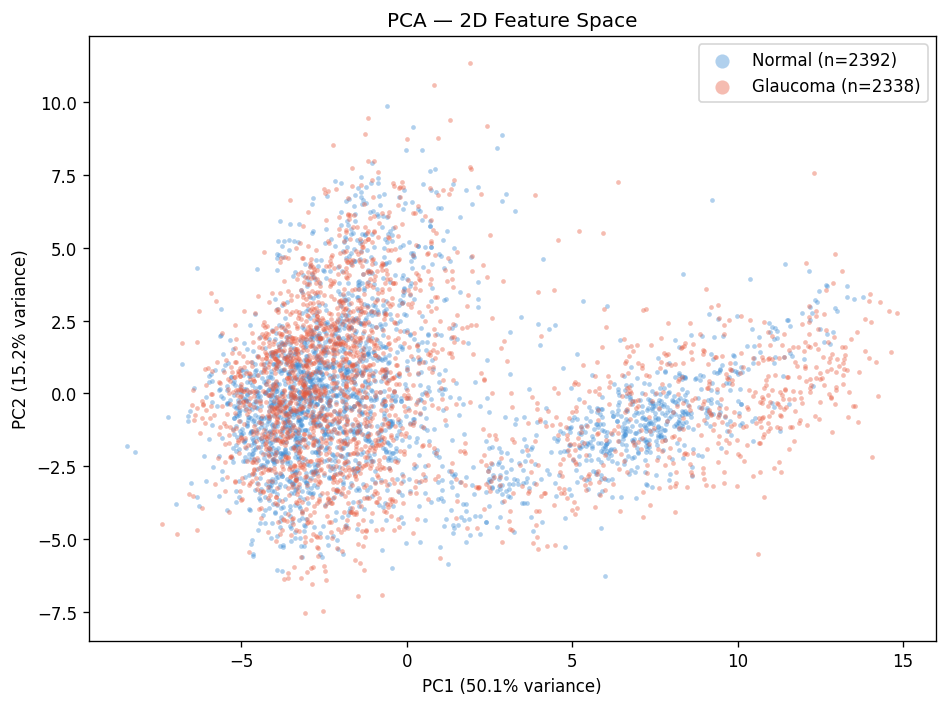

PC1 + PC2 explain 65.3% of total variance


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 6))
for label, name, colour in [(0, 'Normal', '#3B8BD4'), (1, 'Glaucoma', '#E8593C')]:
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colour, label=f'{name} (n={mask.sum()})',
               alpha=0.4, s=8, linewidths=0)

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
ax.set_title('PCA — 2D Feature Space')
ax.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_feature_space.png', bbox_inches='tight')
plt.show()

print(f'PC1 + PC2 explain {sum(var_explained):.1f}% of total variance')

## 3.9 LBP pattern visualisation — sample Normal vs Glaucoma

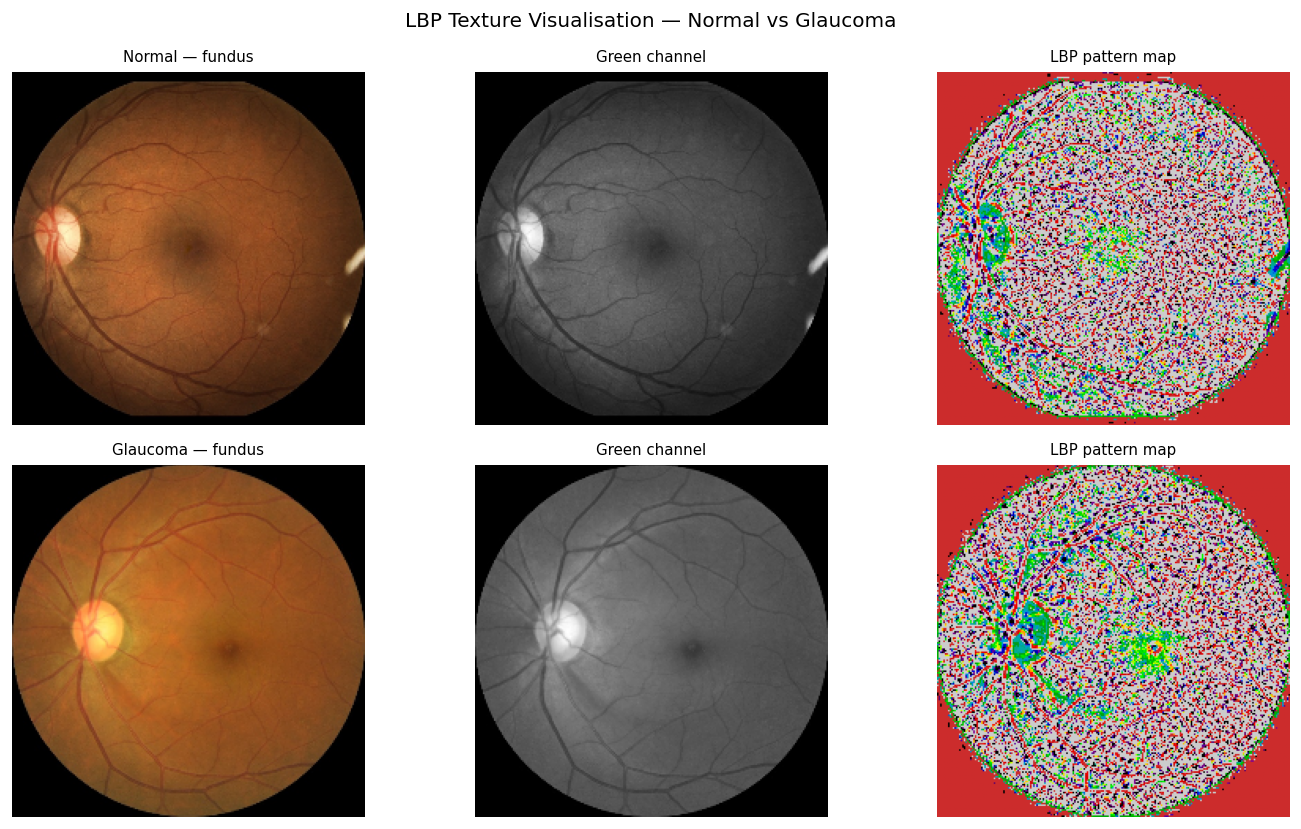

In [12]:
import cv2
from skimage.feature import local_binary_pattern

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for row_idx, (label, title) in enumerate([(0, 'Normal'), (1, 'Glaucoma')]):
    sample = valid_df[valid_df['label'] == label].sample(1, random_state=SEED).iloc[0]
    img_bgr = cv2.imread(sample['image_path'])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (224, 224))
    green   = img_rgb[:, :, 1]
    lbp_map = local_binary_pattern(green, 24, 3, method='uniform')

    # Colour (ax 0)
    axes[row_idx][0].imshow(img_rgb)
    axes[row_idx][0].set_title(f'{title} — fundus', fontsize=9)
    axes[row_idx][0].axis('off')

    # Green channel (ax 1)
    axes[row_idx][1].imshow(green, cmap='gray')
    axes[row_idx][1].set_title('Green channel', fontsize=9)
    axes[row_idx][1].axis('off')

    # LBP map (ax 2)
    axes[row_idx][2].imshow(lbp_map, cmap='nipy_spectral')
    axes[row_idx][2].set_title('LBP pattern map', fontsize=9)
    axes[row_idx][2].axis('off')

plt.suptitle('LBP Texture Visualisation — Normal vs Glaucoma', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lbp_visualisation.png', bbox_inches='tight')
plt.show()

## 3.10 DRISHTI CDR ground-truth vs proxy validation
Measures how well our proxy CDR correlates with expert-annotated CDR.
This quantifies proxy reliability — important to report in the paper.

[DRISHTI] Train images : 50
          With OD mask : 50
          With cup mask: 50
          With CDR     : 50  (mean CDR = 0.704)
          Fully valid  : 50
  Note: test split has no public GT — train-only for segmentation.
Pearson r  : 0.549  (p=0.0000)
Spearman r : 0.557  (p=0.0000)
MAE        : 0.194

Interpretation:
  Pearson r > 0.5 → proxy is a reasonable CDR estimate
  After Phase 7 (U-Net), proxy will be replaced with accurate CDR


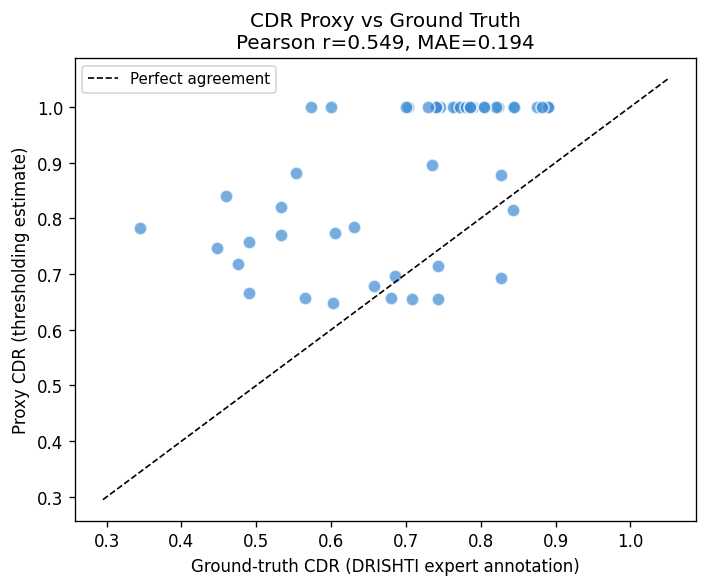

In [13]:
from scipy.stats import pearsonr, spearmanr
from features.feature_extractor import extract_cdr_proxy
import cv2
from data.dataset_loader import load_drishti_segmentation

drishti_df = load_drishti_segmentation()
drishti_valid = drishti_df.dropna(subset=['cdr_mean']).copy()

# Compute proxy CDR for each DRISHTI image
proxy_vals, gt_vals = [], []
for _, row in drishti_valid.iterrows():
    img_bgr = cv2.imread(row['image_path'])
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (224, 224))
    proxy_vals.append(extract_cdr_proxy(img_rgb))
    gt_vals.append(row['cdr_mean'])

proxy_arr = np.array(proxy_vals)
gt_arr    = np.array(gt_vals)

pearson_r,  p_pearson  = pearsonr(gt_arr, proxy_arr)
spearman_r, p_spearman = spearmanr(gt_arr, proxy_arr)
mae = np.mean(np.abs(proxy_arr - gt_arr))

print(f'Pearson r  : {pearson_r:.3f}  (p={p_pearson:.4f})')
print(f'Spearman r : {spearman_r:.3f}  (p={p_spearman:.4f})')
print(f'MAE        : {mae:.3f}')
print(f'\nInterpretation:')
print(f'  Pearson r > 0.5 → proxy is a reasonable CDR estimate')
print(f'  After Phase 7 (U-Net), proxy will be replaced with accurate CDR')

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(gt_arr, proxy_arr, alpha=0.7, color='#3B8BD4', edgecolors='white', s=60)
lims = [min(gt_arr.min(), proxy_arr.min()) - 0.05,
        max(gt_arr.max(), proxy_arr.max()) + 0.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect agreement')
ax.set_xlabel('Ground-truth CDR (DRISHTI expert annotation)')
ax.set_ylabel('Proxy CDR (thresholding estimate)')
ax.set_title(f'CDR Proxy vs Ground Truth\nPearson r={pearson_r:.3f}, MAE={mae:.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cdr_proxy_vs_gt.png', bbox_inches='tight')
plt.show()


---
## ✅ Phase 3 complete

Verify before moving on:
- Feature matrix shape is `(~4700, 45)`
- `features_cache.pkl` saved to `outputs/results/`
- CDR proxy distribution shows glaucoma shifted right (higher CDR)
- PCA plot shows partial class separation

**Next → `03_classical_ml.ipynb`**  
Train Logistic Regression, SVM, and Random Forest on these features.